<a href="https://colab.research.google.com/github/engwjdan/Web-Scraping-Project/blob/main/%D9%85%D8%B4%D8%B1%D9%88%D8%B9_%D8%B9%D9%84%D9%85_%D8%A8%D9%8A%D8%A7%D9%86%D8%A7%D8%AA_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Information
**Student Name:** Wejdan Moawiya Saad  
**Student ID:** 2320223644  
**Course Name:** Data Science  
**Instructor:** Eng. Nour Abu Rukba

#Step 1: Setup and imports
# !pip install requests beautifulsoup4 pandas matplotlib

In [ ]:


import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import matplotlib.pyplot as plt
import random
import os

In [ ]:


# The URL we want to check
url = "https://www.nationalgeographic.com/science/"

# Setting the headers to mimic a real browser
headers = {"User-Agent": "Mozilla/5.0"}

# Sending the request to the website
response = requests.get(url, headers=headers)

# Printing the Status Code
print(f"Status Code: {response.status_code}")

# Final validation
if response.status_code == 200:
    print("Success! The website is ready for scraping ✅")
else:
    print("Failed! Connection error or access denied ❌")

Status Code: 200
Success! The website is ready for scraping ✅


  National Geographic Web Scraper v3
  Features: 7 columns + Image Download
Scraping section: Animals...
Found 16 articles in Animals.
Current total: 16 rows.
Scraping section: Science...
Found 16 articles in Science.
Current total: 32 rows.
Scraping section: Travel...
Found 16 articles in Travel.
Current total: 48 rows.
Scraping section: Environment...
Found 15 articles in Environment.
Current total: 63 rows.
Scraping section: History...
Found 14 articles in History.
Current total: 77 rows.
Scraping section: Adventure...
Found 15 articles in Adventure.
Current total: 92 rows.
Scraping section: Photography...
Found 15 articles in Photography.
Current total: 107 rows.
Scraping section: Animals-Reference...
Error scraping Animals-Reference: 404 Client Error: Not Found for url: https://www.nationalgeographic.com/animals/reference/
Current total: 107 rows.
Scraping section: Science-Space...
Found 15 articles in Science-Space.
Current total: 122 rows.
Scraping section: Science-Health...
Err

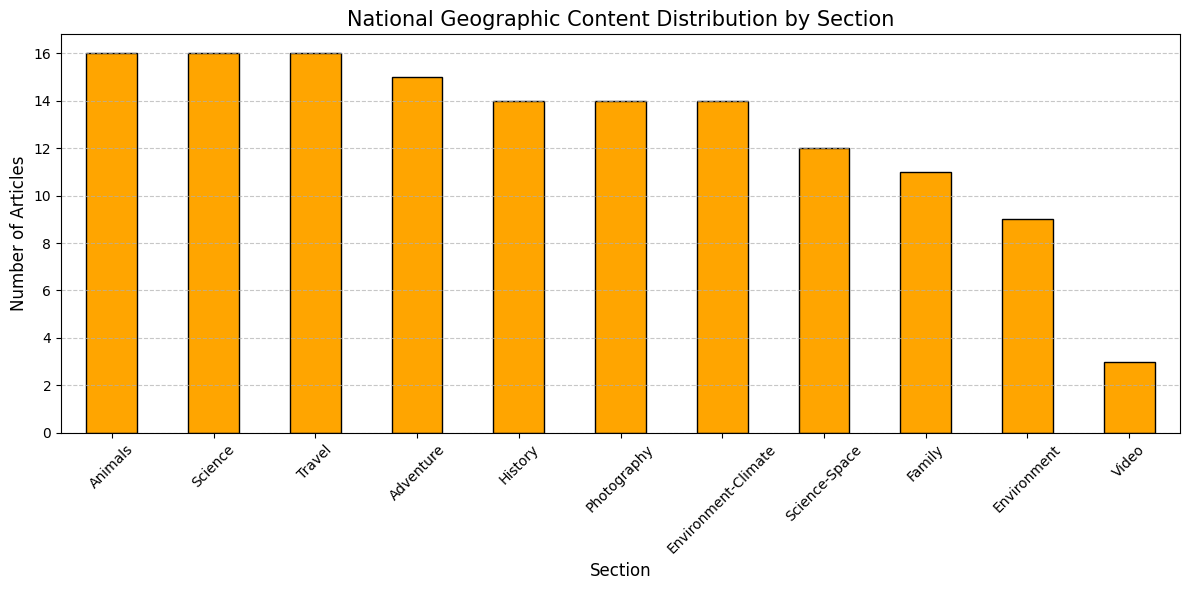

In [ ]:


# Step 2: Define the scraping function with find() and find_all()
def scrape_natgeo_section(section_url, section_name, target_count=100):
    """
    Scrapes a specific section of National Geographic.
    Uses find() and find_all() to extract data.
    """
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
    }

    all_data = []
    seen_urls = set()

    print(f"Scraping section: {section_name}...")

    try:
        response = requests.get(section_url, headers=headers, timeout=15)
        response.raise_for_status()
        soup = BeautifulSoup(response.text, 'html.parser')

        # Step 4: Store data in lists (using a list of dictionaries)
        # Find all article containers
        promos = soup.find_all(['div', 'article'], class_=lambda x: x and ('Promo' in x or 'Tile' in x or 'Grid' in x))

        for promo in promos:
            # Use find() to get specific elements within the container
            link_tag = promo.find('a', href=True)
            if not link_tag:
                continue

            url = link_tag['href']
            if not url.startswith('http'):
                url = "https://www.nationalgeographic.com" + url

            if url in seen_urls or '/article/' not in url:
                continue
            seen_urls.add(url)

            # Extract Title using find()
            title = "N/A"
            title_tag = promo.find(['h2', 'h3', 'span'], class_=lambda x: x and 'Title' in x)
            if not title_tag:
                title_tag = promo.find(['h2', 'h3'])
            if title_tag:
                title = title_tag.get_text(strip=True)

            # Extract Description using find()
            description = "N/A"
            desc_tag = promo.find(['p', 'div'], class_=lambda x: x and 'Description' in x)
            if not desc_tag:
                desc_tag = promo.find('p')
            if desc_tag:
                description = desc_tag.get_text(strip=True)

            # Extract Image URL if available
            image_url = "N/A"
            img_tag = promo.find('img')
            if img_tag and img_tag.get('src'):
                image_url = img_tag['src']
            elif img_tag and img_tag.get('data-src'):
                image_url = img_tag['data-src']

            # Extract Author (if available)
            author = "N/A"
            author_tag = promo.find(['span', 'div', 'a'], class_=lambda x: x and ('Author' in x or 'Byline' in x))
            if author_tag:
                author = author_tag.get_text(strip=True)

            # Extract Date (if available)
            date = "N/A"
            date_tag = promo.find(['time', 'span'], class_=lambda x: x and ('Date' in x or 'Time' in x))
            if date_tag:
                date = date_tag.get_text(strip=True)
            elif promo.find('time'):
                date = promo.find('time').get_text(strip=True)

            if title != "N/A" and len(title) > 5:
                all_data.append({
                    "Title": title,
                    "Description": description,
                    "URL": url,
                    "Category": section_name,
                    "Image_URL": image_url,
                    "Author": author,
                    "Date": date
                })

            if len(all_data) >= target_count:
                break

        print(f"Found {len(all_data)} articles in {section_name}.")
        return all_data

    except Exception as e:
        print(f"Error scraping {section_name}: {e}")
        return []

# ===== NEW: Function to download images and save them in a folder =====
def download_images(df, folder_name="natgeo_images"):
    """
    Downloads all images from the DataFrame and saves them in a folder.
    Uses the Image_URL column to get image links.
    """
    # Create the folder if it doesn't exist
    if not os.path.exists(folder_name):
        os.makedirs(folder_name)
        print(f"Created folder: {folder_name}")

    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
    }

    downloaded = 0
    failed = 0

    print(f"\nStarting image download... Total images to download: {len(df)}")

    for index, row in df.iterrows():
        image_url = row['Image_URL']

        # Skip if no image URL
        if image_url == "N/A" or not image_url.startswith('http'):
            failed += 1
            continue

        try:
            # Create a clean filename from the title
            # Remove special characters and limit length
            clean_title = "".join(c for c in row['Title'] if c.isalnum() or c == ' ')
            clean_title = clean_title[:50].strip()  # Limit to 50 characters

            # Determine file extension from URL
            if '.jpg' in image_url or '.jpeg' in image_url:
                ext = '.jpg'
            elif '.png' in image_url:
                ext = '.png'
            elif '.webp' in image_url:
                ext = '.webp'
            else:
                ext = '.jpg'  # Default to jpg

            # Create filename: index_title.ext
            filename = f"{index+1}_{clean_title}{ext}"
            filepath = os.path.join(folder_name, filename)

            # Download the image
            img_response = requests.get(image_url, headers=headers, timeout=10)
            img_response.raise_for_status()

            # Save the image to the folder
            with open(filepath, 'wb') as f:
                f.write(img_response.content)

            downloaded += 1

            # Print progress every 10 images
            if downloaded % 10 == 0:
                print(f"Downloaded {downloaded} images...")

            # Small delay to be respectful
            time.sleep(0.5)

        except Exception as e:
            failed += 1
            continue

    print(f"\n--- Image Download Complete ---")
    print(f"Successfully downloaded: {downloaded} images")
    print(f"Failed/Skipped: {failed} images")
    print(f"Images saved in folder: '{folder_name}'")

    return downloaded, failed


# Step 3: Loop through multiple pages (sections) to reach 500+ rows
def main():
    # To reach 500+ rows, we include more sections and sub-sections
    sections = {
        "Animals": "https://www.nationalgeographic.com/animals/",
        "Science": "https://www.nationalgeographic.com/science/",
        "Travel": "https://www.nationalgeographic.com/travel/",
        "Environment": "https://www.nationalgeographic.com/environment/",
        "History": "https://www.nationalgeographic.com/history/",
        "Adventure": "https://www.nationalgeographic.com/adventure/",
        "Photography": "https://www.nationalgeographic.com/photography/",
        "Animals-Reference": "https://www.nationalgeographic.com/animals/reference/",
        "Science-Space": "https://www.nationalgeographic.com/science/space/",
        "Science-Health": "https://www.nationalgeographic.com/science/health/",
        "Travel-Best-of-the-World": "https://www.nationalgeographic.com/travel/best-of-the-world/",
        "History-Magazine": "https://www.nationalgeographic.com/history/magazine/",
        "Environment-Climate": "https://www.nationalgeographic.com/environment/climate-change/",
        "Family": "https://www.nationalgeographic.com/family/",
        "Video": "https://www.nationalgeographic.com/video/"
    }

    total_extracted_data = []

    print("=" * 60)
    print("  National Geographic Web Scraper v3")
    print("  Features: 7 columns + Image Download")
    print("=" * 60)

    for name, url in sections.items():
        # Scrape each section
        section_data = scrape_natgeo_section(url, name, target_count=100)
        total_extracted_data.extend(section_data)

        # Respectful delay between sections
        time.sleep(random.uniform(2, 4))

        print(f"Current total: {len(total_extracted_data)} rows.")

    # Step 5: Convert to DataFrame and save as CSV
    if total_extracted_data:
        df = pd.DataFrame(total_extracted_data)

        # Remove any duplicates
        df = df.drop_duplicates(subset=['URL'])

        print(f"\nFinal total unique articles collected: {len(df)}")
        print(f"Columns (7): {list(df.columns)}")

        # Save to CSV
        filename = "natgeo_comprehensive_data.csv"
        df.to_csv(filename, index=False)
        print(f"Data saved to {filename}")

        # ===== NEW: Download images to folder =====
        download_images(df, folder_name="natgeo_images")

        # Step 6: Data analysis and visualization
        perform_analysis(df)
    else:
        print("No data collected.")

def perform_analysis(df):
    """
    Basic data analysis and visualization.
    """
    print("\n--- Data Analysis Report ---")
    print(f"Total Rows: {len(df)}")
    print(f"Total Columns: {len(df.columns)}")
    print(f"Columns: {list(df.columns)}")

    # Category distribution
    category_counts = df['Category'].value_counts()
    print("\nArticles per Category:")
    print(category_counts)

    # Visualization
    plt.figure(figsize=(12, 6))
    category_counts.plot(kind='bar', color='orange', edgecolor='black')
    plt.title('National Geographic Content Distribution by Section', fontsize=15)
    plt.xlabel('Section', fontsize=12)
    plt.ylabel('Number of Articles', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()

    plt.savefig('natgeo_v3_analysis.png')
    print("\nVisualization saved as 'natgeo_v3_analysis.png'")
    plt.show()

if __name__ == "__main__":
    main()